Laboratorium 3
Kaja Thiel 21310


In [13]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [14]:
mnist_dataset, mnist_info = tfds.load(name="mnist", as_supervised=True, with_info=True)
mnist_train, mnist_test = mnist_dataset["train"], mnist_dataset["test"]
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [15]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [16]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [17]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)


(6000, 28, 28, 1) (6000,)


In [18]:
input_size = 784
output_size = 10

hidden_layer_size = 50

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8832 - loss: 0.4128 - val_accuracy: 0.9398 - val_loss: 0.2038
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9495 - loss: 0.1732 - val_accuracy: 0.9532 - val_loss: 0.1561
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9620 - loss: 0.1296 - val_accuracy: 0.9573 - val_loss: 0.1374
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9685 - loss: 0.1060 - val_accuracy: 0.9633 - val_loss: 0.1206
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9733 - loss: 0.0908 - val_accuracy: 0.9655 - val_loss: 0.1173
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9759 - loss: 0.0789 - val_accuracy: 0.9692 - val_loss: 0.1085
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9796 - loss: 0.0687 - val_accuracy: 0.9682 - val_loss: 0.1110
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9821 - loss: 0.0604 - val_accuracy

In [20]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%' .format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step - accuracy: 0.9698 - loss: 0.1005
Test loss: 0.10. Test accuracy: 96.98%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prawdopodobieństwa dla klas od 0 do 9:
[[3.0599645e-16 2.3097504e-21 1.2485681e-12 4.4260631e-07 0.0000000e+00
  9.9999952e-01 2.9624086e-21 4.9860545e-19 3.8372929e-13 4.8616068e-26]]

ROZPOZNANA CYFRA TO: 5 



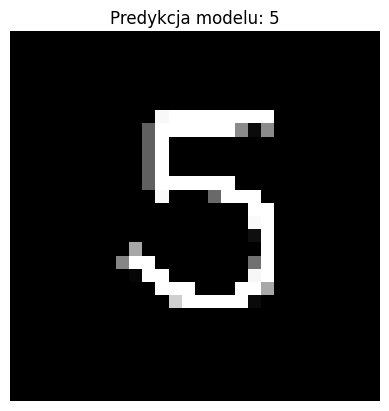

In [21]:
image_path = 'sample_data/cyfra.png'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is not None:
    img_resized = cv2.resize(img, (28, 28))

    img_inverted = cv2.bitwise_not(img_resized)

    img_normalized = img_inverted / 255.0

    img_ready = np.expand_dims(img_normalized, axis=0)
    img_ready = np.expand_dims(img_ready, axis=-1)

    predictions = model.predict(img_ready)

    predicted_digit = np.argmax(predictions)

    print(f"Prawdopodobieństwa dla klas od 0 do 9:\n{predictions}")
    print(f"\nROZPOZNANA CYFRA TO: {predicted_digit} \n")

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Predykcja modelu: {predicted_digit}")
    plt.axis('off')
    plt.show()
else:
    print(f"Nie znaleziono pliku '{image_path}'.")